In [157]:
import pandas as pd
import numpy as np
import yfinance as yf

import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

In [158]:
# ---------------------------------------------------
# Data Import
# ---------------------------------------------------
ticker = "^NSEI"

df = yf.download(
    ticker,
    start="2015-01-01",
    end=None,
    auto_adjust=True
)

df.head()

# ---------------------------------------------------
# OHLCV Input
# ---------------------------------------------------
df = df[['Open','High','Low','Close','Volume']]

df.dropna(inplace=True)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2015-01-02,8288.700195,8410.599609,8288.700195,8395.450195,101900
2015-01-05,8407.950195,8445.599609,8363.900391,8378.400391,118200
2015-01-06,8325.299805,8327.849609,8111.350098,8127.350098,172800
2015-01-07,8118.649902,8151.200195,8065.450195,8102.100098,164100
2015-01-08,8191.399902,8243.500000,8167.299805,8234.599609,143800


In [159]:
# ---------------------------------------------------
# Returns
# ---------------------------------------------------
df["Return"] = df["Close"].pct_change()


# ---------------------------------------------------
# Features
# ---------------------------------------------------

# SMA
df["SMA10"] = df["Close"].rolling(10).mean()
df["SMA50"] = df["Close"].rolling(50).mean()

df["SMA_ratio"] = df["SMA10"] / df["SMA50"]


# Bollinger Bands
rolling_mean = df["Close"].rolling(20).mean()
rolling_std  = df["Close"].rolling(20).std()

upper = rolling_mean + 2 * rolling_std
lower = rolling_mean - 2 * rolling_std

df["BB_width"] = (upper - lower) / rolling_mean


# RSI
delta = df["Close"].diff()

gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()

rs = gain / loss

df["RSI"] = 100 - (100 / (1 + rs))


# Volatility features
df["Volatility_20"] = df["Return"].rolling(20).std()
df["Volatility_60"] = df["Return"].rolling(60).std()

# Volatility change
df["Vol_change_5"] = df["Volatility_20"] - df["Volatility_20"].shift(5)


# Momentum
df["Momentum"] = df["Close"] / df["Close"].rolling(50).mean() - 1


# Drawdown
rolling_high = df["Close"].rolling(60).max()
df["Drawdown"] = df["Close"] / rolling_high - 1


# Gap
df["Gap"] = df["Open"] / df["Close"].shift(1) - 1


# Volume Ratio
df["Volume_ratio"] = df["Volume"] / df["Volume"].rolling(20).mean()


# ---------------------------------------------------
# TARGET (FOR TRAINING ONLY)
# ---------------------------------------------------
df["Future_volatility"] = (
    df["Return"]
    .rolling(20)
    .std()
    .shift(-20)
)


# ---------------------------------------------------
# SHIFT FEATURES (STRICT NO-LOOKAHEAD)
# ---------------------------------------------------
feature_cols = [
    "SMA10","SMA50","SMA_ratio","BB_width","RSI",
    "Volatility_20","Volatility_60","Vol_change_5",
    "Momentum","Drawdown","Gap","Volume_ratio"
]

df[feature_cols] = df[feature_cols].shift(1)


# ---------------------------------------------------
# CLEAN DATA
# ---------------------------------------------------
df = df.dropna().copy()

In [160]:
# ---------------------------------------------------
# WQ Alpha Adaptations
# ---------------------------------------------------

# Alpha 1: Volatility regime instability
df["Alpha1"] = -(df["Volatility_60"] - df["Volatility_20"])

# Alpha 2: Momentum + volatility interaction
df["Alpha2"] = df["Momentum"] * df["Vol_change_5"]

# Alpha 3: Conditional volatility signal
signal = (df["Volatility_20"] - df["Volatility_60"]) / df["Volatility_60"]

threshold = (
    signal.rolling(60).mean() +
    signal.rolling(60).std()
)

df["Alpha3_raw"] = np.where(
    signal > threshold,
    df["Vol_change_5"],
    0
)

df["Alpha3"] = df["Alpha3_raw"].rolling(5).mean()


# ---------------------------------------------------
# Normalize Alphas
# ---------------------------------------------------

alpha_cols = ["Alpha1", "Alpha2", "Alpha3"]

for col in alpha_cols:
    df[col] = (
        (df[col] - df[col].rolling(60).mean()) /
        df[col].rolling(60).std()
    )


# ---------------------------------------------------
# Combined Alpha Signal
# ---------------------------------------------------

df["Alpha_signal"] = (
    0.4 * df["Alpha1"] +
    0.3 * df["Alpha2"] +
    0.3 * df["Alpha3"]
)

In [161]:
# ---------------------------------------------------
# Feature Selection (NO TARGET CREATION HERE)
# ---------------------------------------------------

features = [
    "SMA_ratio",
    "BB_width",
    "RSI",
    "Volatility_20",
    "Volatility_60",
    "Vol_change_5",
    "Volume_ratio",
    "Momentum",
    "Drawdown",
    "Gap"
]

# Inputs
X = df[features]

# Target (continuous volatility)
y = df["Future_volatility"]

In [162]:
# ---------------------------------------------------
# Train-Test Split (TIME BASED)
# ---------------------------------------------------

split_date = "2022-01-01"

train = df[df.index < split_date]
test  = df[df.index >= split_date]


# ---------------------------------------------------
# Create Train/Test Sets
# ---------------------------------------------------

X_train = train[features]
y_train = train["Future_volatility"]

X_test  = test[features]
y_test  = test["Future_volatility"]


# ---------------------------------------------------
# Model Training
# ---------------------------------------------------

from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

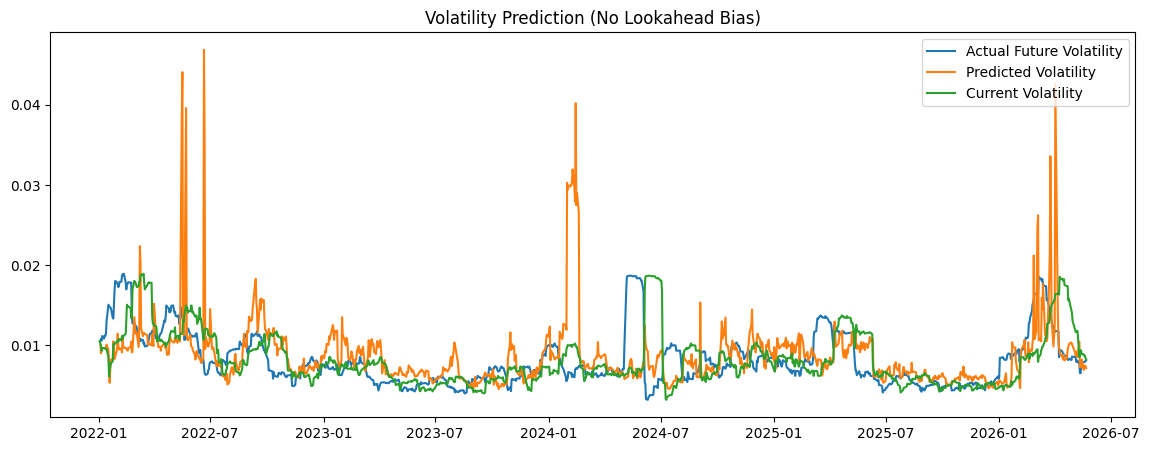

In [163]:
# ---------------------------------------------------
# Predictions
# ---------------------------------------------------

# Use existing test from Block 3 (DO NOT recreate)

test["Predicted_volatility"] = model.predict(X_test)

# ---------------------------------------------------
# CRITICAL: Remove lookahead bias
# ---------------------------------------------------
test["Predicted_volatility"] = test["Predicted_volatility"].shift(1)


test.head()


# ---------------------------------------------------
# Plot Predictions vs Actual
# ---------------------------------------------------

plt.figure(figsize=(14,5))

plt.plot(
    test.index,
    test["Future_volatility"],
    label="Actual Future Volatility"
)

plt.plot(
    test.index,
    test["Predicted_volatility"],
    label="Predicted Volatility"
)

plt.plot(
    test.index,
    test["Volatility_20"],
    label="Current Volatility"
)

plt.legend()

plt.title("Volatility Prediction (No Lookahead Bias)")

plt.show()

In [164]:
# ---------------------------------------------------
# Regression Evaluation
# ---------------------------------------------------

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Drop NaNs caused by shift
valid = test.dropna()

y_true = valid["Future_volatility"]
y_pred = valid["Predicted_volatility"]

# Metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 0.004866975772240354
MAE: 0.002801689052530485
R2: -1.1344700542847335


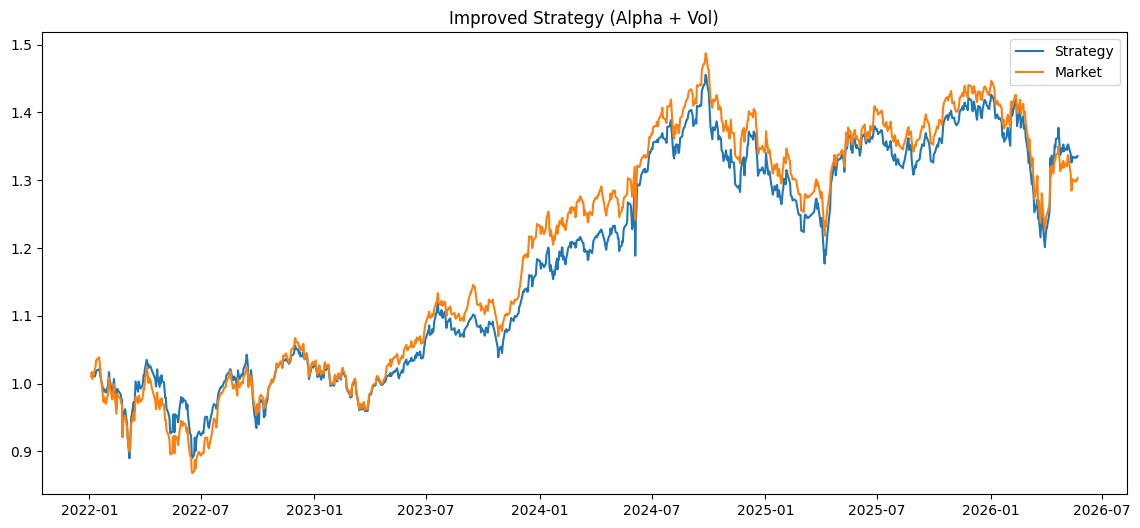

In [165]:
# ---------------------------------------------------
# Strategy (Alpha + Volatility Overlay)
# ---------------------------------------------------

test = test.dropna().copy()

# Smooth prediction
test["Predicted_volatility"] = test["Predicted_volatility"].rolling(5).mean()

# Signals
alpha = test["Alpha_signal"]
vol_filter = test["Predicted_volatility"] - test["Volatility_20"]

# Combined signal
final_signal = 0.7 * alpha - 0.5 * vol_filter

# Position
test["Position"] = np.where(
    final_signal > 0.5, 1.5,
    np.where(final_signal < -0.5, 0.5, 1.0)
)

# Smooth + execution lag
test["Position"] = test["Position"].rolling(3).mean().shift(1)


# ---------------------------------------------------
# Costs
# ---------------------------------------------------

cost_per_trade = 0.0005
slippage = 0.0005

test["Turnover"] = test["Position"].diff().abs()
test["Cost"] = (cost_per_trade + slippage) * test["Turnover"]

risk_free_daily = 0.06 / 252
test["Leverage"] = np.maximum(test["Position"] - 1, 0)
test["Funding_Cost"] = test["Leverage"] * risk_free_daily


# ---------------------------------------------------
# Returns
# ---------------------------------------------------

test["Strategy_Return"] = (
    test["Position"] * test["Return"]
    - test["Cost"]
    - test["Funding_Cost"]
)

test["Cumulative_Strategy"] = (1 + test["Strategy_Return"]).cumprod()
test["Cumulative_Market"] = (1 + test["Return"]).cumprod()

# ---------------------------------------------------
# Plot
# ---------------------------------------------------
plt.figure(figsize=(14,6))
plt.plot(test.index, test["Cumulative_Strategy"], label="Strategy")
plt.plot(test.index, test["Cumulative_Market"], label="Market")
plt.legend()
plt.title("Improved Strategy (Alpha + Vol)")
plt.show()

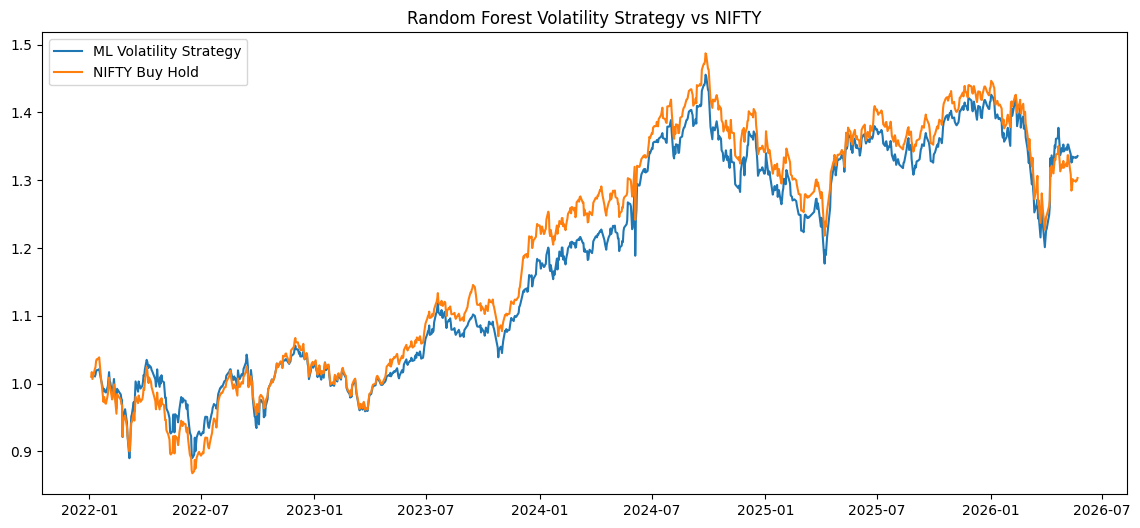

ML Strategy Return: 33.58 %
NIFTY Return: 30.34 %
0.5207635333463502


In [166]:
# ---------------------------------------------------
# Equity Curve & Final metrics
# ---------------------------------------------------

#Equity Curve
test["Strategy_Curve"] = (

    1+

    test["Strategy_Return"]

).cumprod()

# Add 'BuyHold_Return' column, using the existing 'Return' column from the test DataFrame
test["BuyHold_Return"] = test["Return"]

test["NIFTY_Curve"] = (

    1+

    test["BuyHold_Return"]

).cumprod()



plt.figure(figsize=(14,6))


plt.plot(
    test.index,
    test["Strategy_Curve"],
    label="ML Volatility Strategy"
)


plt.plot(
    test.index,
    test["NIFTY_Curve"],
    label="NIFTY Buy Hold"
)


plt.legend()

plt.title(
    "Random Forest Volatility Strategy vs NIFTY"
)


plt.show()

#Final Metrics
strategy_return = (
    test["Strategy_Curve"].iloc[-1]-1
)


nifty_return = (
    test["NIFTY_Curve"].iloc[-1]-1
)


print(
"ML Strategy Return:",
round(strategy_return*100,2),
"%"
)


print(
"NIFTY Return:",
round(nifty_return*100,2),
"%"
)
print(test["Strategy_Return"].mean() / test["Strategy_Return"].std() * np.sqrt(252))